## Problem: make your small image recognition neural network

#### Data: MNIST

#### Models to play with:

- A shallow Multi-Layer Perceptron (MLP)
- Convolutional Neural Network (CNN)
- Transformer (Encoder)
Additionally, there is good opportunity to add test "%" by doing different image augmentations.

## Setup

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1000)

In [5]:
## Create noise test set
class AddNoise:
    def __call__(self, img):
        noise = torch.randn_like(img) * 0.2
        return img + noise

noise_transform = transforms.Compose([
    transforms.ToTensor(),
    AddNoise(),
    transforms.Normalize((0.5,), (0.5,))
])

test_noise_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=noise_transform
)

test_noise_loader = DataLoader(test_noise_dataset, batch_size=1000)

In [7]:
def show_samples(loader):
    images, labels = next(iter(loader))

    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(images[i].squeeze(), cmap='gray')
        ax.set_title(f"Label: {labels[i].item()}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

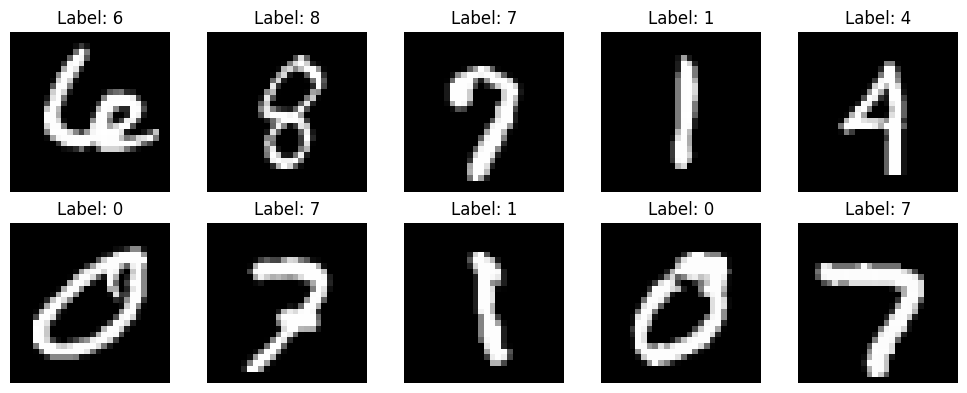

In [8]:
show_samples(train_loader)

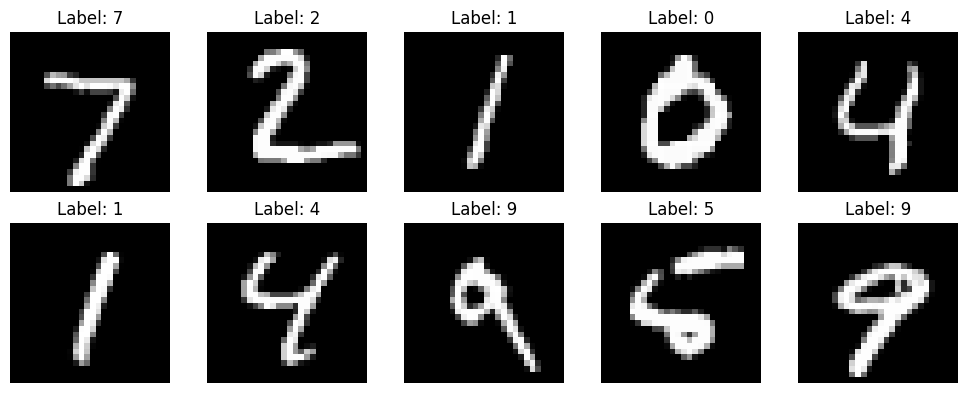

In [9]:
show_samples(test_loader)

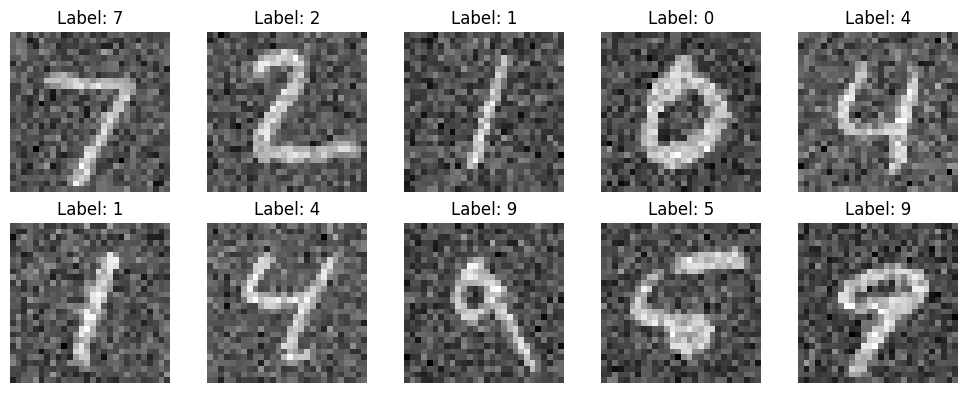

In [10]:
show_samples(test_noise_loader)

## Model

###  Shallow MLP
The Multi-Layer Perceptron (MLP) is a fully connected neural network that processes input data as a one-dimensional vector.

For the MNIST dataset, each image has a size of 28 × 28 pixels. Since an MLP cannot directly handle 2D spatial structure, the image is first flattened into a vector of length 784 (28 × 28).

The architecture used in this model is:

- Input layer: 784 neurons (flattened image)
- Hidden layer 1: 256 neurons with ReLU activation
- Hidden layer 2: 128 neurons with ReLU activation
- Output layer: 10 neurons (one for each digit class 0–9)

In [11]:
# Flattened size
print("\n=== MLP Input ===")
print("Flattened size (28x28):", 28 * 28)
print("Flattened tensor shape:", image.view(-1).shape)


=== MLP Input ===
Flattened size (28x28): 784
Flattened tensor shape: torch.Size([784])


In [12]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

In [13]:
model = MLP()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

results = {}

# ===== TRAIN =====
for epoch in range(5):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x, y in train_loader:
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = correct / total
    train_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")

# ===== TEST FUNCTION =====
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            outputs = model(x)
            preds = outputs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

# ===== CLEAN TEST =====
clean_acc = evaluate(model, test_loader)
results["MLP_Clean"] = clean_acc

print(f"\nMLP Clean Test Accuracy: {clean_acc:.4f}")

# ===== NOISE TEST =====
noise_acc = evaluate(model, test_noise_loader)
results["MLP_Noise"] = noise_acc

print(f"MLP Noise Test Accuracy: {noise_acc:.4f}")

Epoch 1 | Loss: 0.3373 | Train Acc: 0.8982
Epoch 2 | Loss: 0.1519 | Train Acc: 0.9534
Epoch 3 | Loss: 0.1102 | Train Acc: 0.9657
Epoch 4 | Loss: 0.0881 | Train Acc: 0.9725
Epoch 5 | Loss: 0.0775 | Train Acc: 0.9748

MLP Clean Test Accuracy: 0.9694
MLP Noise Test Accuracy: 0.9608


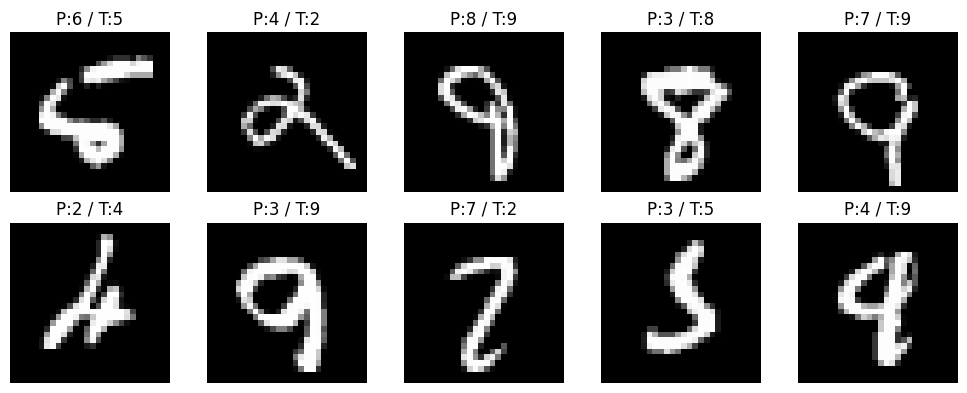

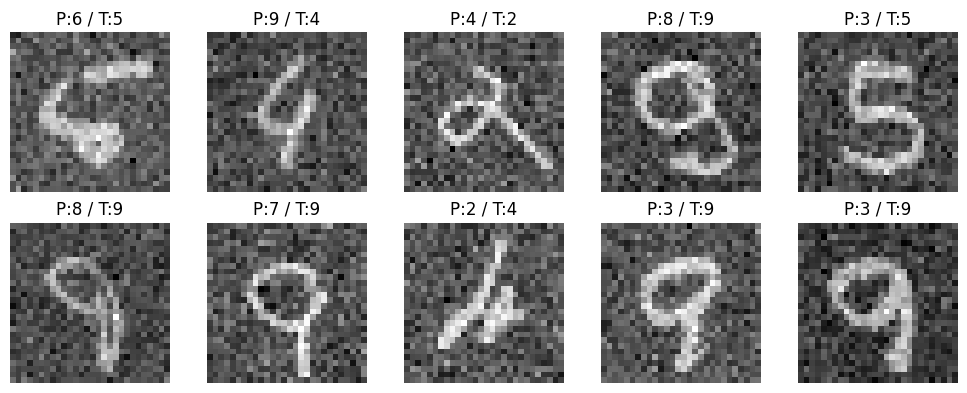

In [14]:
## Visualize incorrect predictions -- clean test set
incorrect_images = []
incorrect_preds = []
incorrect_labels = []

with torch.no_grad():
    for x, y in test_loader:
        outputs = model(x)
        preds = outputs.argmax(dim=1)

        # find wrong predictions
        mask = preds != y

        incorrect_images.append(x[mask].cpu())
        incorrect_preds.append(preds[mask].cpu())
        incorrect_labels.append(y[mask].cpu())

        if len(incorrect_images) > 5:
            break

# flatten lists
incorrect_images = torch.cat(incorrect_images)[:10]
incorrect_preds = torch.cat(incorrect_preds)[:10]
incorrect_labels = torch.cat(incorrect_labels)[:10]

# plot
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(incorrect_images[i].squeeze(), cmap='gray')
    ax.set_title(f"P:{incorrect_preds[i].item()} / T:{incorrect_labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## Visualize incorrect predictions -- noise test set
wrong_imgs = []
wrong_preds = []
wrong_labels = []

with torch.no_grad():
    for x, y in test_noise_loader:
        outputs = model(x)
        preds = outputs.argmax(dim=1)

        mask = preds != y

        wrong_imgs.append(x[mask].cpu())
        wrong_preds.append(preds[mask].cpu())
        wrong_labels.append(y[mask].cpu())

        if sum(t.size(0) for t in wrong_imgs) >= 10:
            break

wrong_imgs = torch.cat(wrong_imgs)[:10]
wrong_preds = torch.cat(wrong_preds)[:10]
wrong_labels = torch.cat(wrong_labels)[:10]

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(wrong_imgs[i].squeeze(), cmap="gray")
    ax.set_title(f"P:{wrong_preds[i].item()} / T:{wrong_labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### CNN
The Convolutional Neural Network (CNN) is designed to process image data by preserving spatial structure and learning local patterns such as edges and shapes.

Unlike the MLP, the CNN takes the input image in its original 28 × 28 grayscale format and applies convolutional filters to extract features.

The architecture used in this model is:

- Convolutional layer 1: 32 filters (3 × 3), ReLU activation
- Convolutional layer 2: 64 filters (3 × 3), ReLU activation
- Max pooling layer: 2 × 2
- Fully connected layer: 128 neurons with ReLU activation
- Output layer: 10 neurons (one for each digit class)

In [15]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64*14*14, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

In [16]:
model = CNN()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# ===== TRAIN =====
for epoch in range(5):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x, y in train_loader:
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = correct / total
    train_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")

# ===== TEST FUNCTION =====
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            outputs = model(x)
            preds = outputs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

# ===== CLEAN TEST =====
clean_acc = evaluate(model, test_loader)
results["CNN_Clean"] = clean_acc

print(f"\nCNN Clean Test Accuracy: {clean_acc:.4f}")

# ===== NOISE TEST =====
noise_acc = evaluate(model, test_noise_loader)
results["CNN_Noise"] = noise_acc

print(f"CNN Noise Test Accuracy: {noise_acc:.4f}")

Epoch 1 | Loss: 0.1371 | Train Acc: 0.9590
Epoch 2 | Loss: 0.0389 | Train Acc: 0.9879
Epoch 3 | Loss: 0.0237 | Train Acc: 0.9923
Epoch 4 | Loss: 0.0159 | Train Acc: 0.9947
Epoch 5 | Loss: 0.0111 | Train Acc: 0.9962

CNN Clean Test Accuracy: 0.9901
CNN Noise Test Accuracy: 0.9826


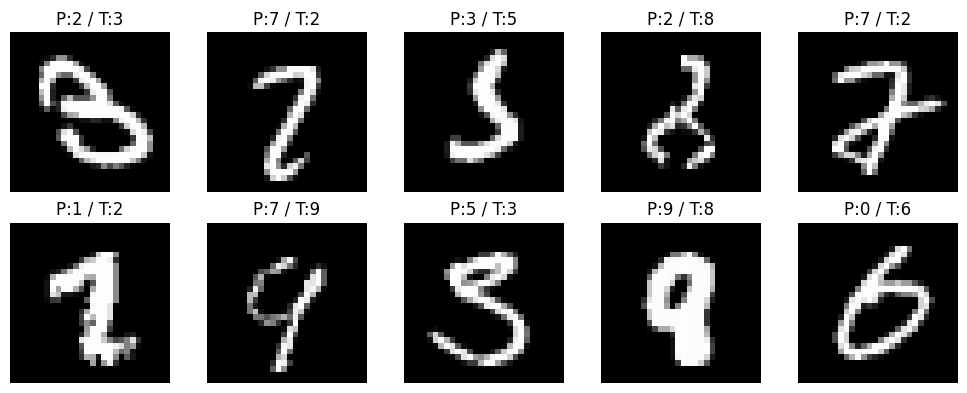

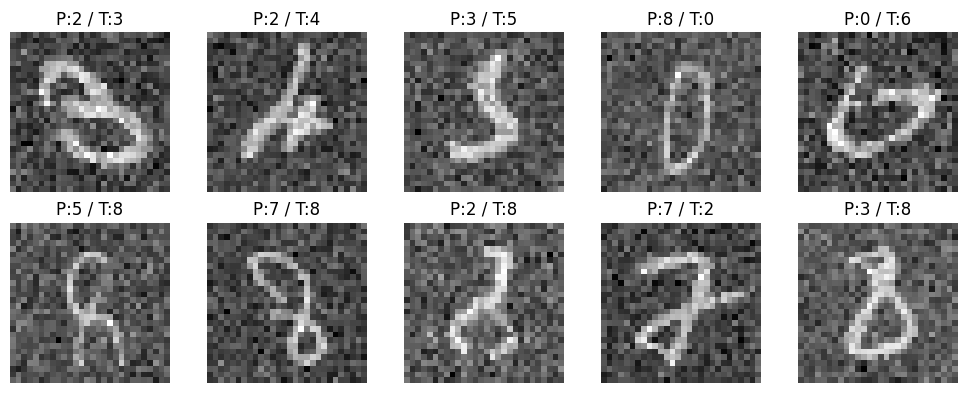

In [17]:
## Visualize incorrect predictions -- clean test set
incorrect_images = []
incorrect_preds = []
incorrect_labels = []

with torch.no_grad():
    for x, y in test_loader:
        outputs = model(x)
        preds = outputs.argmax(dim=1)

        # find wrong predictions
        mask = preds != y

        incorrect_images.append(x[mask].cpu())
        incorrect_preds.append(preds[mask].cpu())
        incorrect_labels.append(y[mask].cpu())

        if len(incorrect_images) > 5:
            break

# flatten lists
incorrect_images = torch.cat(incorrect_images)[:10]
incorrect_preds = torch.cat(incorrect_preds)[:10]
incorrect_labels = torch.cat(incorrect_labels)[:10]

# plot
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(incorrect_images[i].squeeze(), cmap='gray')
    ax.set_title(f"P:{incorrect_preds[i].item()} / T:{incorrect_labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## Visualize incorrect predictions -- noise test set
wrong_imgs = []
wrong_preds = []
wrong_labels = []

with torch.no_grad():
    for x, y in test_noise_loader:
        outputs = model(x)
        preds = outputs.argmax(dim=1)

        mask = preds != y

        wrong_imgs.append(x[mask].cpu())
        wrong_preds.append(preds[mask].cpu())
        wrong_labels.append(y[mask].cpu())

        if sum(t.size(0) for t in wrong_imgs) >= 10:
            break

wrong_imgs = torch.cat(wrong_imgs)[:10]
wrong_preds = torch.cat(wrong_preds)[:10]
wrong_labels = torch.cat(wrong_labels)[:10]

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(wrong_imgs[i].squeeze(), cmap="gray")
    ax.set_title(f"P:{wrong_preds[i].item()} / T:{wrong_labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Transformer

The Transformer model is based on a self-attention mechanism, which allows it to model relationships between different parts of the input. Instead of using convolutions, it processes the image as a sequence of patches.

In this implementation, the 28 × 28 image is divided into smaller patches (e.g., 4 × 4), and each patch is treated as a token in a sequence.

The architecture consists of:

- Patch embedding: each image patch is flattened and projected into a feature vector
- Positional encoding: added to retain spatial order information
- Transformer encoder layers (multi-head self-attention + feedforward layers)
- Global pooling layer
- Output layer: 10 neurons (digit classes)

In [18]:
class TransformerModel(nn.Module):
    def __init__(self, patch_size=4, emb_dim=64, num_heads=4, num_layers=2):
        super().__init__()

        self.patch_size = patch_size
        self.num_patches = (28 // patch_size) ** 2
        self.patch_dim = patch_size * patch_size

        self.linear_proj = nn.Linear(self.patch_dim, emb_dim)

        self.pos_embedding = nn.Parameter(torch.randn(1, self.num_patches, emb_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=num_heads,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Linear(emb_dim, 10)

    def forward(self, x):
        B, C, H, W = x.shape

        # split into patches
        x = x.unfold(2, self.patch_size, self.patch_size)\
             .unfold(3, self.patch_size, self.patch_size)
        x = x.contiguous().view(B, -1, self.patch_dim)

        x = self.linear_proj(x)
        x = x + self.pos_embedding

        x = self.transformer(x)

        x = x.mean(dim=1)  # global average pooling
        return self.classifier(x)

In [19]:
model = TransformerModel()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# ===== TRAIN =====
for epoch in range(5):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x, y in train_loader:
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = correct / total
    train_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")

# ===== TEST FUNCTION =====
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            outputs = model(x)
            preds = outputs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

# ===== CLEAN TEST =====
clean_acc = evaluate(model, test_loader)
results["Transformer_Clean"] = clean_acc

print(f"\nTransformer Clean Test Accuracy: {clean_acc:.4f}")

# ===== NOISE TEST =====
noise_acc = evaluate(model, test_noise_loader)
results["Transformer_Noise"] = noise_acc

print(f"Transformer Noise Test Accuracy: {noise_acc:.4f}")

Epoch 1 | Loss: 0.5526 | Train Acc: 0.8144
Epoch 2 | Loss: 0.1742 | Train Acc: 0.9471
Epoch 3 | Loss: 0.1307 | Train Acc: 0.9594
Epoch 4 | Loss: 0.1062 | Train Acc: 0.9670
Epoch 5 | Loss: 0.0919 | Train Acc: 0.9712

Transformer Clean Test Accuracy: 0.9765
Transformer Noise Test Accuracy: 0.9662


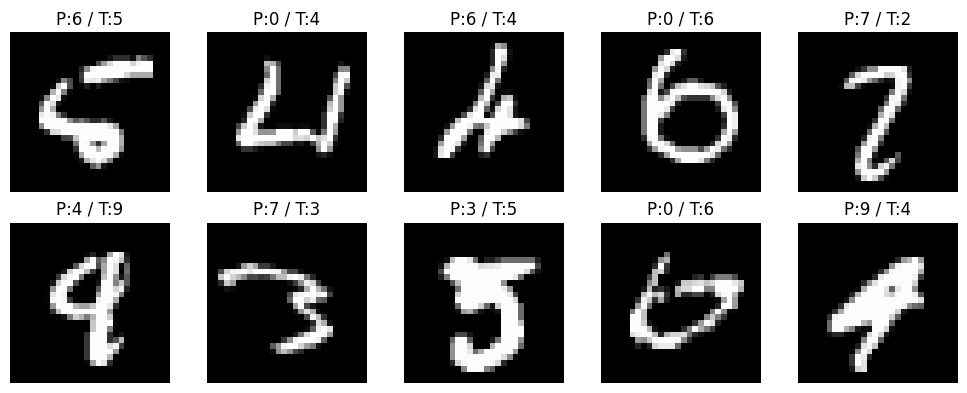

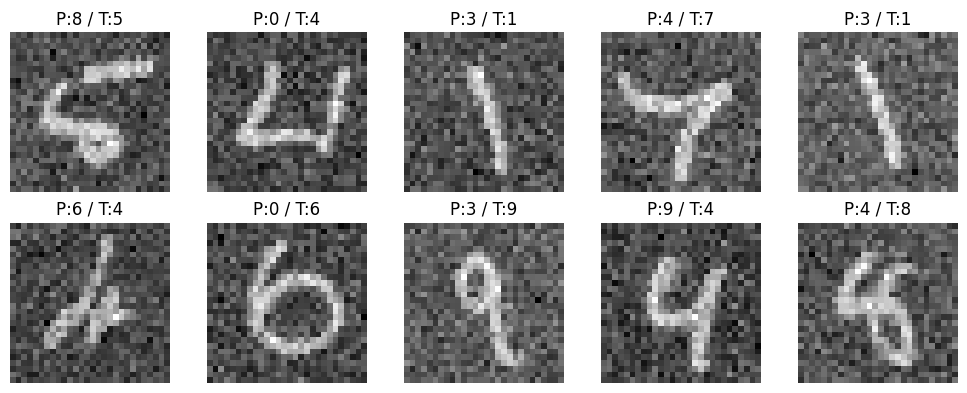

In [20]:
## Visualize incorrect predictions -- clean test set
incorrect_images = []
incorrect_preds = []
incorrect_labels = []

with torch.no_grad():
    for x, y in test_loader:
        outputs = model(x)
        preds = outputs.argmax(dim=1)

        # find wrong predictions
        mask = preds != y

        incorrect_images.append(x[mask].cpu())
        incorrect_preds.append(preds[mask].cpu())
        incorrect_labels.append(y[mask].cpu())

        if len(incorrect_images) > 5:
            break

# flatten lists
incorrect_images = torch.cat(incorrect_images)[:10]
incorrect_preds = torch.cat(incorrect_preds)[:10]
incorrect_labels = torch.cat(incorrect_labels)[:10]

# plot
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(incorrect_images[i].squeeze(), cmap='gray')
    ax.set_title(f"P:{incorrect_preds[i].item()} / T:{incorrect_labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## Visualize incorrect predictions -- noise test set
wrong_imgs = []
wrong_preds = []
wrong_labels = []

with torch.no_grad():
    for x, y in test_noise_loader:
        outputs = model(x)
        preds = outputs.argmax(dim=1)

        mask = preds != y

        wrong_imgs.append(x[mask].cpu())
        wrong_preds.append(preds[mask].cpu())
        wrong_labels.append(y[mask].cpu())

        if sum(t.size(0) for t in wrong_imgs) >= 10:
            break

wrong_imgs = torch.cat(wrong_imgs)[:10]
wrong_preds = torch.cat(wrong_preds)[:10]
wrong_labels = torch.cat(wrong_labels)[:10]

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(wrong_imgs[i].squeeze(), cmap="gray")
    ax.set_title(f"P:{wrong_preds[i].item()} / T:{wrong_labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Model Comparisons

         Model  Clean Accuracy (%)  Noisy Accuracy (%)
0          MLP               96.94               96.08
1          CNN               99.01               98.26
2  Transformer               97.65               96.62


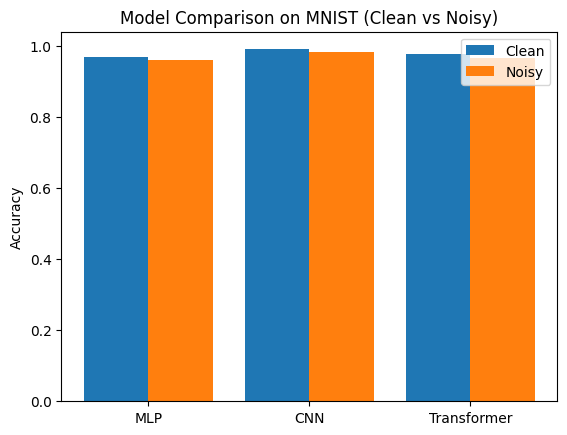

In [27]:
data = {
    "Model": ["MLP", "CNN", "Transformer"],
    "Clean Accuracy (%)": [
        results["MLP_Clean"] * 100,
        results["CNN_Clean"] * 100,
        results["Transformer_Clean"] * 100
    ],
    "Noisy Accuracy (%)": [
        results["MLP_Noise"] * 100,
        results["CNN_Noise"] * 100,
        results["Transformer_Noise"] * 100
    ]
}

df = pd.DataFrame(data)
print(df)

models = ["MLP", "CNN", "Transformer"]

clean_scores = [
    results["MLP_Clean"],
    results["CNN_Clean"],
    results["Transformer_Clean"]
]

noise_scores = [
    results["MLP_Noise"],
    results["CNN_Noise"],
    results["Transformer_Noise"]
]

x = np.arange(len(models))

plt.bar(x - 0.2, clean_scores, width=0.4, label="Clean")
plt.bar(x + 0.2, noise_scores, width=0.4, label="Noisy")

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Model Comparison on MNIST (Clean vs Noisy)")
plt.legend()
plt.show()


=== Final Model Comparison ===
MLP_Clean: 0.9694
MLP_Noise: 0.9608
CNN_Clean: 0.9901
CNN_Noise: 0.9826
Transformer_Clean: 0.9765
Transformer_Noise: 0.9662


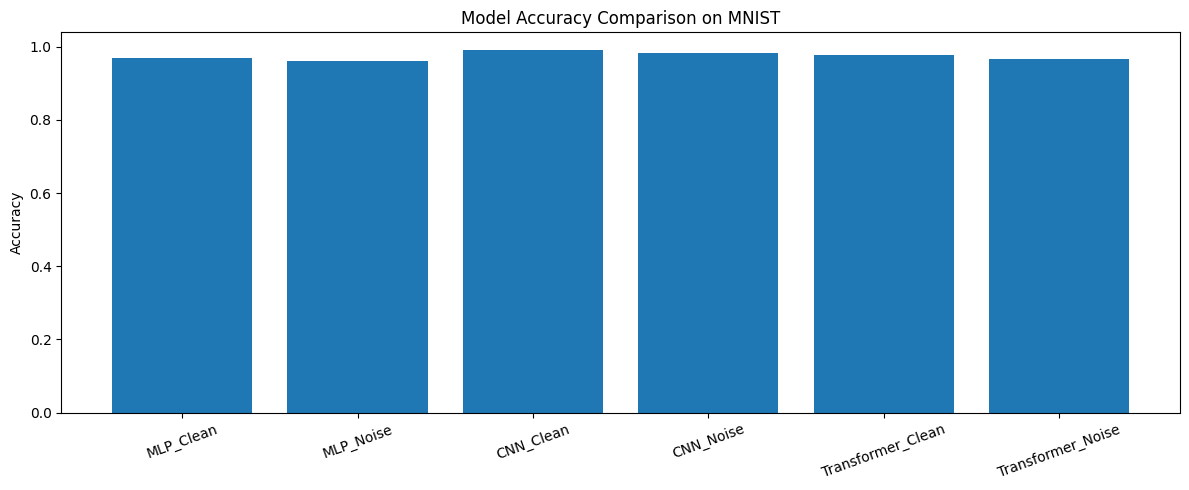

In [29]:
print("\n=== Final Model Comparison ===")
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")

plt.figure(figsize=(12, 5))  # wider plot
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison on MNIST")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Based on the evaluation results:

- **CNN performed best overall** with the highest accuracy on both clean and noisy data  
    - Clean: **99.01%**
    - Noisy: **98.26%**
- **Transformer ranked second**, showing strong performance but slightly lower robustness than CNN  
    - Clean: **97.65%**
    - Noisy: **96.62%**
- **MLP had the lowest accuracy**, though still performed reasonably well  
    - Clean: **96.94%**
    - Noisy: **96.08%**


All models experienced a small accuracy drop under noise, but the **CNN achieved the best balance of accuracy and robustness**, making it the strongest choice for this MNIST task.